In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import date, timedelta

In [8]:
# Load CSV
df = pd.read_csv("Nat_Gas.csv")

# Rename columns for clarity
df.columns = ["date", "price"]

# Convert date column
df["date"] = pd.to_datetime(df["date"])

/var/folders/61/9_bd7j9j0rx2v0c23wplfm180000gn/T/ipykernel_10079/2275208795.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [10]:
df = df.sort_values("date")
df.set_index("date", inplace=True)

In [11]:
df.head()

,price
date,
2020-10-31,10.1
2020-11-30,10.3
2020-12-31,11.0
2021-01-31,10.9
2021-02-28,10.9


In [13]:
df["t"] = np.arange(len(df))
df.head()

,price,t
date,,
2020-10-31,10.1,0
2020-11-30,10.3,1
2020-12-31,11.0,2
2021-01-31,10.9,3
2021-02-28,10.9,4


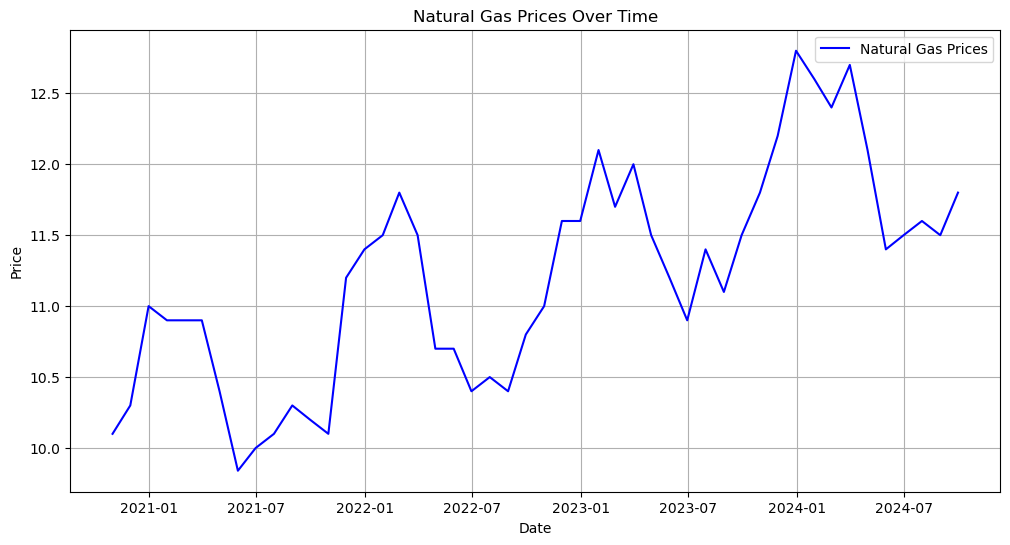

In [15]:
# visualize the data
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["price"], label="Natural Gas Prices", color="blue")
plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [16]:
# Seasonal components (annual seasonality)
df["sin_12"] = np.sin(2 * np.pi * df["t"] / 12)
df["cos_12"] = np.cos(2 * np.pi * df["t"] / 12)

In [17]:
# Design matrix
X = np.column_stack([
    np.ones(len(df)),
    df["t"],
    df["sin_12"],
    df["cos_12"]
])

In [36]:
X[:10]  # Display first 5 rows of design matrix

array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00],
       [ 1.00000000e+00,  1.00000000e+00,  5.00000000e-01,
         8.66025404e-01],
       [ 1.00000000e+00,  2.00000000e+00,  8.66025404e-01,
         5.00000000e-01],
       [ 1.00000000e+00,  3.00000000e+00,  1.00000000e+00,
         6.12323400e-17],
       [ 1.00000000e+00,  4.00000000e+00,  8.66025404e-01,
        -5.00000000e-01],
       [ 1.00000000e+00,  5.00000000e+00,  5.00000000e-01,
        -8.66025404e-01],
       [ 1.00000000e+00,  6.00000000e+00,  1.22464680e-16,
        -1.00000000e+00],
       [ 1.00000000e+00,  7.00000000e+00, -5.00000000e-01,
        -8.66025404e-01],
       [ 1.00000000e+00,  8.00000000e+00, -8.66025404e-01,
        -5.00000000e-01],
       [ 1.00000000e+00,  9.00000000e+00, -1.00000000e+00,
        -1.83697020e-16]])

In [ ]:
y = df["price"].values

# Ordinary Least Squares
beta = np.linalg.lstsq(X, y, rcond=None)[0] # OLS coefficients

In [ ]:
def estimate_gas_price(input_date):
    """
    Returns estimated natural gas price for any date
    (past or up to 1 year in the future).
    """
    input_date = pd.to_datetime(input_date)

    # Convert date to months since start
    months_since_start = (
        (input_date.year - df.index[0].year) * 12 + (input_date.month - df.index[0].month)
    )

    sin_term = np.sin(2 * np.pi * months_since_start / 12)
    cos_term = np.cos(2 * np.pi * months_since_start / 12)

    X_new = np.array([
        1,
        months_since_start,
        sin_term,
        cos_term
    ])

    return float(X_new @ beta)

In [20]:
estimate_gas_price("2022-06-15")
estimate_gas_price("2025-03-31")

12.930842757206692

In [21]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.offsets.MonthEnd(1),
    periods=12,
    freq="M"
)

future_prices = [estimate_gas_price(d) for d in future_dates]

/var/folders/61/9_bd7j9j0rx2v0c23wplfm180000gn/T/ipykernel_10079/270981048.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


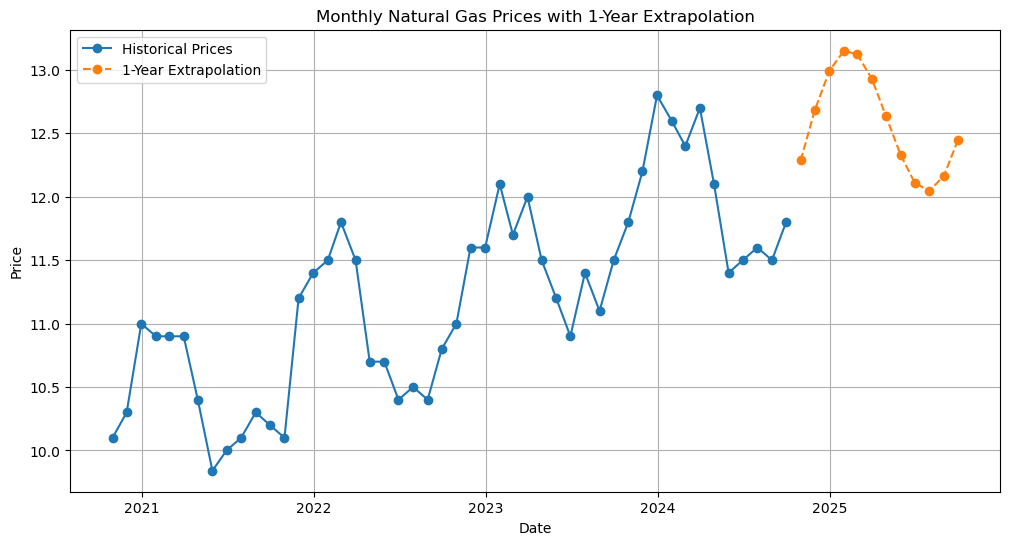

In [22]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["price"], label="Historical Prices", marker="o")
plt.plot(future_dates, future_prices, label="1-Year Extrapolation", linestyle="--", marker="o")

plt.title("Monthly Natural Gas Prices with 1-Year Extrapolation")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


/var/folders/61/9_bd7j9j0rx2v0c23wplfm180000gn/T/ipykernel_10079/3387029035.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("Nat_Gas.csv", parse_dates=["Dates"])
/var/folders/61/9_bd7j9j0rx2v0c23wplfm180000gn/T/ipykernel_10079/3387029035.py:8: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  ax.plot_date(dates, prices, "-")


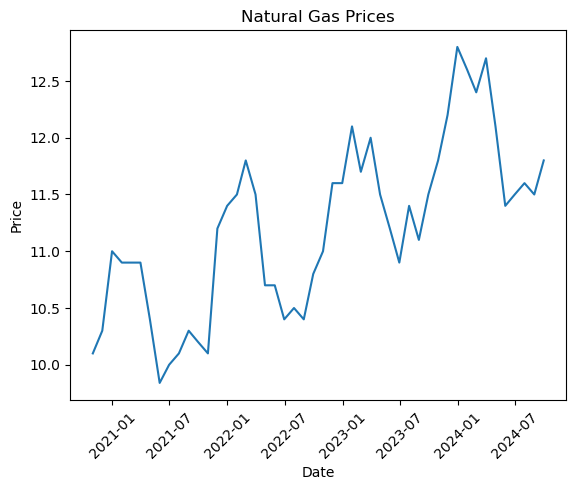

In [26]:
##### JPM #####
df = pd.read_csv("Nat_Gas.csv", parse_dates=["Dates"])

prices = df["Prices"].values
dates = df["Dates"].values

fig, ax = plt.subplots()
ax.plot_date(dates, prices, "-")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.set_title("Natural Gas Prices")
ax.tick_params(axis="x", rotation=45)
plt.show()

In [ ]:
start_date = date(2020, 10, 31)
end_date = date(2024, 9, 30)

months = []
year = start_date.year # 
month = start_date.month + 1 # Initialize month

while True:
    current = date(year, month, 1) + timedelta(days=-1)
    months.append(current)
    if current.month == end_date.month and current.year == end_date.year:
        break
    month = ((month + 1) % 12) or 12
    if month == 1:
        year += 1

days_from_start = [(day - start_date).days for day in months]


In [29]:
def simple_regression(x, y):
    xbar = np.mean(x)
    ybar = np.mean(y)
    slope = np.sum((x - xbar) * (y - ybar)) / np.sum((x - xbar) ** 2)
    intercept = ybar - slope * xbar
    return slope, intercept

time = np.array(days_from_start)
slope, intercept = simple_regression(time, prices)

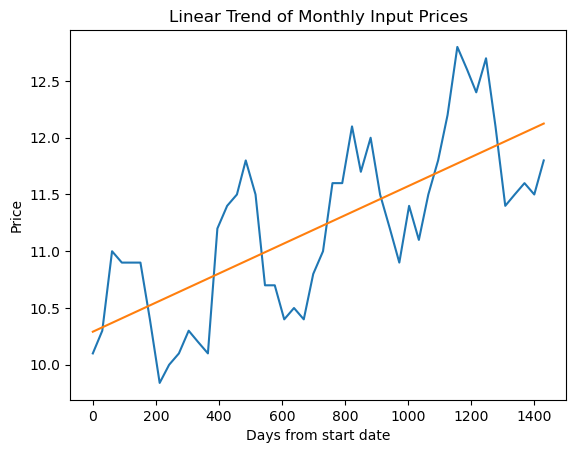

In [30]:
plt.plot(time, prices)
plt.plot(time, time * slope + intercept)
plt.xlabel("Days from start date")
plt.ylabel("Price")
plt.title("Linear Trend of Monthly Input Prices")
plt.show()


In [31]:
sin_prices = prices - (time * slope + intercept)

sin_time = np.sin(time * 2 * np.pi / 365)
cos_time = np.cos(time * 2 * np.pi / 365)

In [32]:
def bilinear_regression(y, x1, x2):
    slope1 = np.sum(y * x1) / np.sum(x1 ** 2)
    slope2 = np.sum(y * x2) / np.sum(x2 ** 2)
    return slope1, slope2

slope1, slope2 = bilinear_regression(sin_prices, sin_time, cos_time)

amplitude = np.sqrt(slope1 ** 2 + slope2 ** 2)
shift = np.arctan2(slope2, slope1)

In [33]:
def interpolate(input_date):
    days = (input_date - pd.Timestamp(start_date)).days

    if days in days_from_start:
        return prices[days_from_start.index(days)]
    else:
        return (
            amplitude * np.sin(days * 2 * np.pi / 365 + shift)
            + days * slope
            + intercept
        )

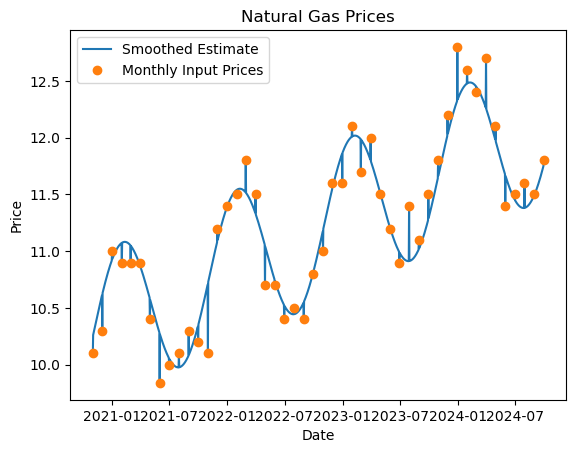

In [34]:
continuous_dates = pd.date_range(
    start=pd.Timestamp(start_date),
    end=pd.Timestamp(end_date),
    freq="D"
)

plt.plot(
    continuous_dates,
    [interpolate(d) for d in continuous_dates],
    label="Smoothed Estimate"
)

plt.plot(dates, prices, "o", label="Monthly Input Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Natural Gas Prices")
plt.legend()
plt.show()
